# Coffea-Casa Benchmark Example 1

In [1]:
import numpy as np
%matplotlib inline
import hist
import coffea.processor as processor
import awkward as ak
from coffea.nanoevents import schemas

In [2]:
# This program plots an event-level variable (in this case, MET, but switching it is as easy as a dict-key change). It also demonstrates an easy use of the book-keeping cutflow tool, to keep track of the number of events processed.

# The processor class bundles our data analysis together while giving us some helpful tools.  It also leaves looping and chunks to the framework instead of us.
class Processor(processor.ProcessorABC):
    def __init__(self):
        # Bins and categories for the histogram are defined here. For format, see https://coffeateam.github.io/coffea/stubs/coffea.hist.hist_tools.Hist.html && https://coffeateam.github.io/coffea/stubs/coffea.hist.hist_tools.Bin.html
        dataset_axis = hist.axis.StrCategory(name="dataset", label="", categories=[], growth=True)
        MET_axis = hist.axis.Regular(name="MET", label="MET [GeV]", bins=50, start=0, stop=100)
        
        # The accumulator keeps our data chunks together for histogramming. It also gives us cutflow, which can be used to keep track of data.
        self.output = processor.dict_accumulator({
            'MET': hist.Hist(dataset_axis, MET_axis),
            'cutflow': processor.defaultdict_accumulator(int)
        })
    
    def process(self, events):
        # This is where we do our actual analysis. The dataset has columns similar to the TTree's; events.columns can tell you them, or events.[object].columns for deeper depth.
        dataset = events.metadata["dataset"]
        MET = events.MET.pt
        
        # We can define a new key for cutflow (in this case 'all events'). Then we can put values into it. We need += because it's per-chunk (demonstrated below)
        self.output['cutflow']['all events'] += len(MET)
        self.output['cutflow']['number of chunks'] += 1
        
        # This fills our histogram once our data is collected. The hist key ('MET=') will be defined in the bin in __init__.
        self.output['MET'].fill(dataset=dataset, MET=MET)
        return self.output
    
    def postprocess(self, accumulator):
        pass

In [3]:
from dask.distributed import Client

client = Client("tls://localhost:8786")

In [22]:
fileset = {'SingleMu':
           {"files":  
             { "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/01919AD6-5EA0-EB47-B21D-89121FC0C8C6.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/055FA10B-C4F0-BD43-AB89-DDBA00814DF6.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/4DD47A6B-2C21-F142-9929-A351DAFD1473.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/567E763E-F1EF-3745-A1DD-3214C8048EA6.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/715DB643-831D-6D47-8540-63F937CF48F4.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/86F1B4C4-76B0-F949-8DB4-90346A679401.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/953EFAF4-0F31-754C-9601-246C549A2E25.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/AB10FBAB-92C0-C043-933D-117FCC5704BA.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/C6E8BB7F-7F54-0C4C-9EDF-479C7DBB12E4.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/CB90AA65-868A-F548-A291-3837A3113162.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/07D89838-5D7E-CC4E-BD6B-6CA67597D89A.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/CF50DAD4-FDE3-D747-A24B-7F7D0B935DE0.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/D5C5C4B1-6A02-5D43-B0C1-16BB2E6145B2.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/F78228AB-4C38-4141-84FE-03928A8D0893.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/0AA3D645-4912-364C-B61D-B41EDD892DE4.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/0F41DD13-E950-5446-A1F1-25DA7AFCB2F5.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/18B53494-657F-5744-8131-58ABA4EE00ED.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/2CCE1139-F301-C341-AE1E-4D27AF294018.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/300C603C-F1DD-4A40-B4DD-F4E0B239A460.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/39251543-EE21-9C4C-80D5-5D9178F55C71.root": "Events",
                "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/3BD29D89-9C4A-E743-8616-C6806281BF12.root": "Events",
            }
           }
          }

executor = processor.DaskExecutor(client=client)

run = processor.Runner(executor=executor,
                        schema=schemas.NanoAODSchema,
                        savemetrics=True
                      )

output, metrics = run(fileset, processor_instance=Processor())

metrics

Preprocessing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25/25 [ 0:00:18 < 0:00:00 | 1.6 file/s ]

Processing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49/49 [ 0:00:42 < 0:00:00 | 1.3 chunk/s ]

{'bytesread': 36136788,
 'columns': [Accessed(branch='MET_pt', buffer_key='87b1c4ac-364f-11ec-a860-0820a8c0beef/%2FEvents%3B1/0-73000/data/MET_pt%2C%21load'),
  Accessed(branch='MET_pt', buffer_key='65f92978-362b-11ec-8a16-19849e86beef/%2FEvents%3B1/0-20000/data/MET_pt%2C%21load'),
  Accessed(branch='MET_pt', buffer_key='7630e8b8-3625-11ec-a500-42013c0abeef/%2FEvents%3B1/0-48000/data/MET_pt%2C%21load'),
  Accessed(branch='MET_pt', buffer_key='c7482f54-35c6-11ec-ad10-98bce183beef/%2FEvents%3B1/740250-846000/data/MET_pt%2C%21load'),
  Accessed(branch='MET_pt', buffer_key='8a0396b4-354a-11ec-ad57-73d09a83beef/%2FEvents%3B1/0-104125/data/MET_pt%2C%21load'),
  Accessed(branch='MET_pt', buffer_key='7fa0a472-3640-11ec-a8bb-25e65d9fbeef/%2FEvents%3B1/0-93600/data/MET_pt%2C%21load'),
  Accessed(branch='MET_pt', buffer_key='d0e2bfd6-3614-11ec-967c-21d09a83beef/%2FEvents%3B1/0-103000/data/MET_pt%2C%21load'),
  Accessed(branch='MET_pt', buffer_key='8a0396b4-354a-11ec-ad57-73d09a83beef/%2FEvents%3B

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fcae9642390>, errorbar=None, legend_artist=None)]

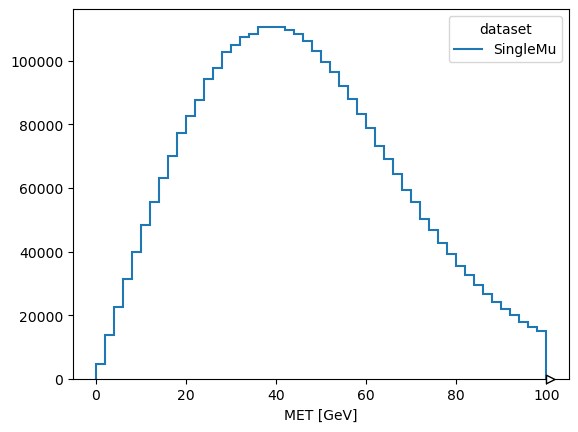

In [23]:
# Generates a 1D histogram from the data output to the 'MET' key. fill_opts are optional, to fill the graph (default is a line).
output['MET'].plot1d()

In [24]:
# Easy way to print all cutflow dict values. Can just do print(output['cutflow']["KEY_NAME"]) for one.
for key, value in output['cutflow'].items():
    print(key, value)

all events 3439000

number of chunks 44

In [ ]:
# all events 53446198
# number of chunks 534